In [34]:
from langchain.chat_models import init_chat_model
from typing import Literal
from pydantic import BaseModel , Field

model = init_chat_model("google_genai:gemini-3-flash-preview")


class GraphSchema(BaseModel):
    input:str = Field(..., description="The input of the post")
    plateform : Literal['insta','twitter','']
    topic:str = Field(..., description="The title of the post")
    post:str = Field(..., description="The post content .")
    category:str = Field(..., description="The post category.")

llm_structure = model.with_structured_output(GraphSchema)

In [35]:
def Decider(state:GraphSchema):
    input = state.input
    output = llm_structure.invoke(f"guess topic and plateform requered for post generation on user input from this {input}")
    return {"topic":output.topic,"plateform":output.plateform}

In [44]:
def insta_node(state:GraphSchema):
    topic=state.topic
    post = llm_structure.invoke(f"Genereate post for insta on {topic}")
    
    return post

def twitter_node(state:GraphSchema):
    topic=state.topic
    post = llm_structure.invoke(f"Genereate post for twitter on {topic}")
    
    return post

In [45]:
from langgraph.graph import END
def condition(state:GraphSchema):
    p = state.plateform
    if p=='insta':
        return "insta_node"
    elif p=='twitter':
        return "twitter_node"
    else :
        return END

In [46]:
from langgraph.graph import END ,StateGraph,START

graph = StateGraph(GraphSchema)
graph.add_node("insta_node",insta_node)
graph.add_node("twitter_node",twitter_node)
graph.add_node("Decider",Decider)

graph.add_edge(START,"Decider")
graph.add_conditional_edges("Decider",condition,{
    "insta_node":"insta_node",
    "twitter_node":"twitter_node"
})

graph.add_edge("twitter_node",END)
graph.add_edge("insta_node",END)

model = graph.compile()


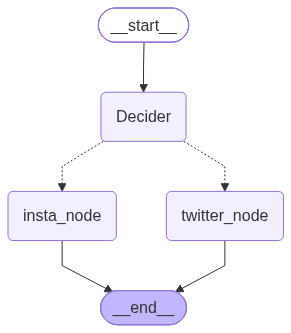

In [47]:
model

In [49]:
model.invoke({
    "input":"popoulation post insta",
    "plateform":"",
    "topic":"",
    "post":"",
    "category":""
})

{'input': 'Genereate post for insta on Global Population Growth',
 'plateform': 'insta',
 'topic': 'Global Population Growth',
 'post': 'The world has officially crossed the 8 billion mark! 🌍 While this milestone reflects improvements in healthcare and longevity, it also brings up crucial conversations about resource management, climate impact, and sustainability. 💡 How can we innovate to ensure a healthy planet for future generations? Share your thoughts below! 👇 #8Billion #PopulationGrowth #Sustainability #GlobalFuture #Environment',
 'category': 'Global Issues'}